<a href="https://colab.research.google.com/github/kimgayeon430/data_analysis_lab/blob/main/ML_classification_regression_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 분류·회귀 & 모델 평가 실습 교안
## (Decision Tree · Naive Bayes · k-NN · Linear Regression · 평가기법 · 앙상블 · 불균형 분류)

> **실습 환경**: Google Colab (Python 3, scikit-learn 기반)

---

### 학습 목차
1. 환경 설정 및 데이터셋 준비
2. **분류 알고리즘**
   - 2-1. Decision Tree (의사결정나무)
   - 2-2. Naive Bayes (나이브 베이즈)
   - 2-3. k-Nearest Neighbors (k-최근접 이웃)
3. **회귀 알고리즘**
   - 3-1. Linear Regression (선형 회귀)
4. **모델 평가 기법**
   - 4-1. Holdout Method (홀드아웃)
   - 4-2. Cross-Validation (교차 검증)
   - 4-3. Bootstrap (부트스트랩)
5. **앙상블 기법**
   - 5-1. Bagging (배깅)
   - 5-2. Random Forest (랜덤 포레스트)
   - 5-3. AdaBoost (에이다부스트)
   - 5-4. XGBoost (익스트림 그래디언트 부스팅)
6. **불균형 데이터 분류 (Class-Imbalanced Classification)**
7. 종합 정리


## 1. 환경 설정 및 데이터셋 준비

Colab에는 대부분의 라이브러리가 설치되어 있으나, `xgboost`와 `imbalanced-learn`(불균형 데이터용)은 버전 확인 차원에서 함께 설치합니다.

In [1]:
# 필요한 패키지 설치 (Colab 기본 설치되어 있어도 안전하게 재설치/업그레이드)
!pip install -q scikit-learn xgboost imbalanced-learn matplotlib seaborn
print("설치 완료")

설치 완료


In [2]:
# 공통 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# 시각화 기본 설정
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
RANDOM_STATE = 42   # 재현성을 위한 고정 시드

# 한글 깨짐 방지를 위한 마이너스 부호 설정
plt.rcParams["axes.unicode_minus"] = False

print("라이브러리 임포트 완료 | numpy", np.__version__, "| pandas", pd.__version__)

라이브러리 임포트 완료 | numpy 2.0.2 | pandas 2.2.2


### 실습용 데이터셋 소개

본 교안에서는 scikit-learn 내장 데이터셋을 사용합니다. 외부 다운로드가 필요 없어 Colab에서 바로 실행됩니다.

| 용도 | 데이터셋 | 설명 |
|------|----------|------|
| 분류(다중) | **Iris** | 붓꽃 품종 3종 분류 (특성 4개) |
| 분류(이진) | **Breast Cancer** | 유방암 악성/양성 진단 (특성 30개) |
| 회귀 | **Diabetes** | 당뇨병 진행도 예측 (연속값) |
| 불균형 분류 | **합성 데이터** | `make_classification`으로 95:5 비율 생성 |

In [3]:
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes

# 1) 분류용 - 붓꽃 (다중 클래스)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# 2) 분류용 - 유방암 (이진 클래스)
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# 3) 회귀용 - 당뇨병
diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target

print("Iris   :", X_iris.shape, "| 클래스:", iris.target_names)
print("Cancer :", X_cancer.shape, "| 클래스:", cancer.target_names)
print("Diabetes:", X_diab.shape, "| 타깃 범위: {:.0f} ~ {:.0f}".format(y_diab.min(), y_diab.max()))

Iris   : (150, 4) | 클래스: ['setosa' 'versicolor' 'virginica']
Cancer : (569, 30) | 클래스: ['malignant' 'benign']
Diabetes: (442, 10) | 타깃 범위: 25 ~ 346


In [4]:
# Iris 데이터를 DataFrame으로 살펴보기
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris["species"] = [iris.target_names[i] for i in y_iris]
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


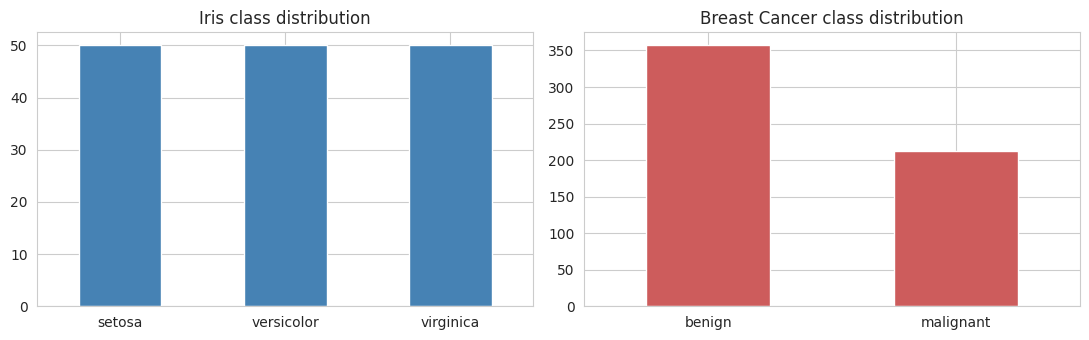

In [5]:
# 클래스 분포 시각화 (분류 데이터가 균형적인지 확인)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
pd.Series(y_iris).map(dict(enumerate(iris.target_names))).value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", title="Iris class distribution")
pd.Series(y_cancer).map({0:"malignant",1:"benign"}).value_counts().plot(
    kind="bar", ax=axes[1], color="indianred", title="Breast Cancer class distribution")
for ax in axes: ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 2. 분류 알고리즘

### 2-1. Decision Tree (의사결정나무)

**개념**
- 데이터를 특성 기준으로 반복적으로 분할(split)하여 트리 형태의 규칙을 만드는 모델입니다.
- 각 분할은 **불순도(impurity)** 를 가장 크게 줄이는 기준으로 선택됩니다. 대표 척도는 **지니 불순도(Gini)** 와 **엔트로피(Entropy)** 입니다.
- **장점**: 해석이 쉽고(규칙을 그림으로 표현), 스케일링 불필요. **단점**: 과적합(overfitting)되기 쉬워 `max_depth` 등으로 제어 필요.

아래에서는 Iris 데이터로 학습한 뒤 트리 구조를 직접 그려봅니다.

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 홀드아웃 분할 (학습 70% / 테스트 30%)
Xtr, Xte, ytr, yte = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=RANDOM_STATE, stratify=y_iris)  #stratify -> 랜덤하게 나눌 떄 클래스 레이블의 비율을 기존 유지  -> 35,35,35

# 모델 학습 (max_depth로 과적합 제어)
dt = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=RANDOM_STATE)  # 트리가 만들어지는 max_depth를 줘서 오버피팅을 피함
dt.fit(Xtr, ytr)

pred = dt.predict(Xte)
print("Accuracy: {:.3f}".format(accuracy_score(yte, pred)))
print()
print(classification_report(yte, pred, target_names=iris.target_names))

Accuracy: 0.933

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



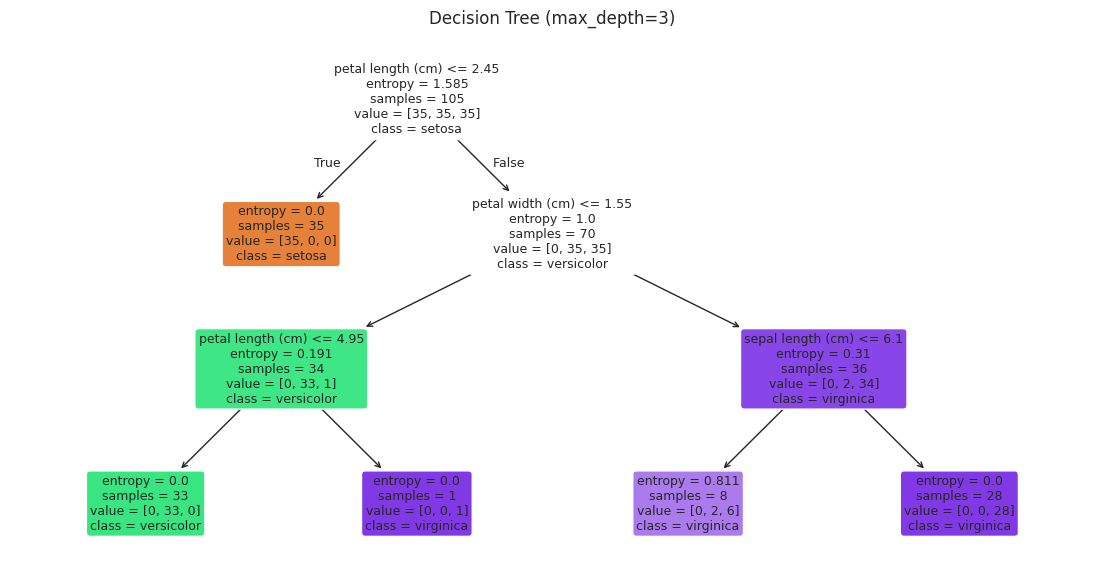

In [7]:
# 트리 구조 시각화
plt.figure(figsize=(14, 7))
plot_tree(dt, feature_names=iris.feature_names, class_names=list(iris.target_names),
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth=3)")
plt.show()

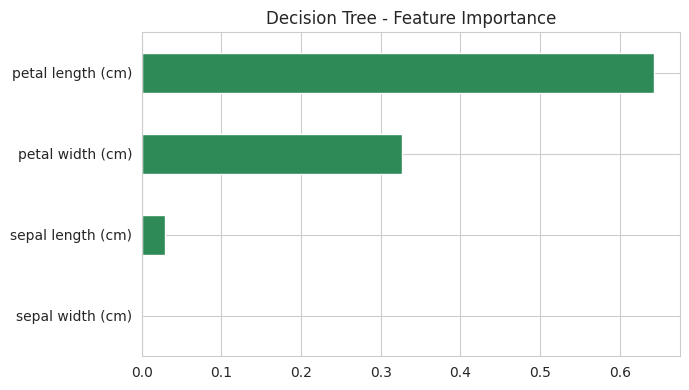

In [8]:
# 특성 중요도 (Feature Importance): 어떤 특성이 분류에 크게 기여했는가
imp = pd.Series(dt.feature_importances_, index=iris.feature_names).sort_values()
imp.plot(kind="barh", color="seagreen", title="Decision Tree - Feature Importance")
plt.tight_layout(); plt.show()  #여기서 petal length는 2개의 질문이 감소시킨 엔트로피를 합산해서 보여줌

**해석 포인트**
- 트리 그림에서 윗부분(루트 근처)의 분할 기준일수록 분류에 중요한 특성입니다.
- `max_depth`를 키우면 학습 정확도는 오르지만 과적합 위험이 커집니다. 직접 1, 5, 10으로 바꿔 테스트 정확도 변화를 관찰해 보세요.

### 2-2. Naive Bayes (나이브 베이즈)

**개념**
- **베이즈 정리**에 기반한 확률적 분류기입니다: $P(y|X) \propto P(X|y)P(y)$
- "**나이브(순진한)**"라는 이름은 *모든 특성이 서로 독립*이라는 (현실에서는 거의 성립하지 않는) 가정을 두기 때문입니다.
- 가정이 단순함에도 텍스트 분류(스팸 필터 등)에서 매우 강력하며, **학습이 빠릅니다**.
- 연속형 특성에는 **GaussianNB**(정규분포 가정)를 주로 사용합니다.

정확도(Accuracy): 0.911
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



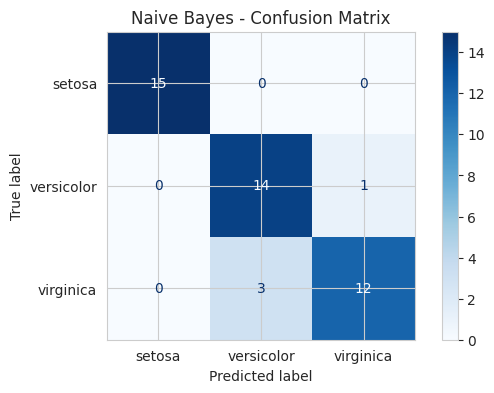

In [9]:
from sklearn.naive_bayes import GaussianNB

Xtr, Xte, ytr, yte = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=RANDOM_STATE, stratify=y_iris)

nb = GaussianNB()
nb.fit(Xtr, ytr)
pred = nb.predict(Xte)

print("정확도(Accuracy): {:.3f}".format(accuracy_score(yte, pred)))
print(classification_report(yte, pred, target_names=iris.target_names))

# 혼동 행렬 시각화
ConfusionMatrixDisplay(confusion_matrix(yte, pred),
                       display_labels=iris.target_names).plot(cmap="Blues")
plt.title("Naive Bayes - Confusion Matrix"); plt.show()

In [10]:
# 클래스별 예측 확률 확인 (확률 기반 모델의 장점)  - 5개의 test case를 어떻게 예측했는지
proba = nb.predict_proba(Xte[:5])
pd.DataFrame(proba, columns=iris.target_names).round(3)

,setosa,versicolor,virginica
0,0.0,0.000,1.000
1,0.0,0.996,0.004
2,0.0,0.847,0.153
3,0.0,0.668,0.332
4,0.0,0.104,0.896


**해석 포인트**
- `predict_proba`로 각 샘플이 어느 클래스에 속할 확률을 직접 확인할 수 있습니다.
- 특성 간 상관관계가 강한 데이터에서는 독립 가정이 깨져 성능이 떨어질 수 있습니다.

### 2-3. k-Nearest Neighbors (k-NN, k-최근접 이웃)

**개념**
- 새로운 데이터가 들어오면 **가장 가까운 k개의 이웃**을 찾아 다수결로 클래스를 정합니다.
- 별도의 "학습" 과정이 거의 없는 **게으른 학습기(lazy learner)** 입니다 — 예측 시점에 거리를 계산합니다.
- **거리 기반**이므로 **스케일링(표준화)이 필수**입니다. 단위가 큰 특성이 거리를 지배하기 때문입니다.
- `k`가 작으면 노이즈에 민감(과적합), 크면 경계가 뭉툭(과소적합)해집니다.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

Xtr, Xte, ytr, yte = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=RANDOM_STATE, stratify=y_cancer)  # cancer data 사용

# 스케일링 + KNN을 파이프라인으로 묶기 (데이터 누수 방지)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn.fit(Xtr, ytr)
pred = knn.predict(Xte)

print("k=5 정확도: {:.3f}".format(accuracy_score(yte, pred)))  # 생각보다 결과 잘 나옴

k=5 정확도: 0.959


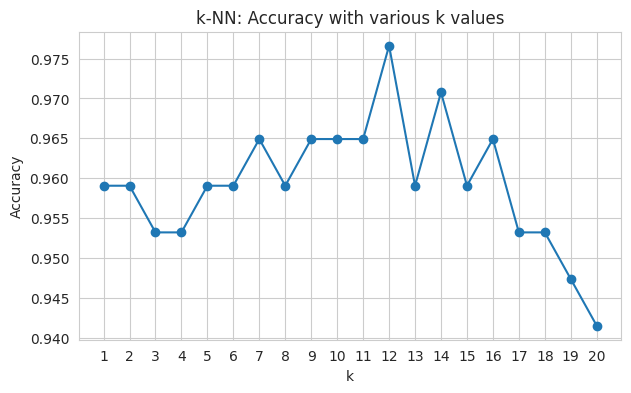

최적 k = 12 (정확도 0.977)


In [12]:
# 최적의 k 찾기: k를 1~20까지 바꿔가며 테스트 정확도 측정  - k값이 무한정 커진다고 좋은게 아니다
ks = range(1, 21)
scores = []
for k in ks:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    m.fit(Xtr, ytr)
    scores.append(accuracy_score(yte, m.predict(Xte)))

plt.plot(list(ks), scores, marker="o")
plt.xlabel("k"); plt.ylabel("Accuracy")
plt.title("k-NN: Accuracy with various k values")
plt.xticks(list(ks)); plt.show()

best_k = list(ks)[int(np.argmax(scores))]
print("최적 k = {} (정확도 {:.3f})".format(best_k, max(scores)))

**해석 포인트**
- 스케일링을 빼고 실행하면 성능이 크게 떨어지는 것을 직접 확인해 보세요.
- 위 그래프에서 정확도가 가장 높은 `k`를 선택하되, 너무 작은 k(=1)는 과적합 위험이 있습니다.

## 3. 회귀 알고리즘

### 3-1. Linear Regression (선형 회귀)

**개념**
- 입력 특성들의 **선형 결합**으로 연속형 타깃을 예측합니다: $\hat{y} = w_0 + w_1 x_1 + \dots + w_n x_n$
- 학습이란 **잔차 제곱합(예측 오차의 제곱 합)** 을 최소화하는 계수 $w$를 찾는 과정입니다.
- 평가 지표: **MSE/RMSE**(오차 크기), **R²**(설명력, 1에 가까울수록 좋음).
- 분류가 아닌 **회귀** 문제이므로 당뇨병 데이터를 사용합니다.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Xtr, Xte, ytr, yte = train_test_split(
    X_diab, y_diab, test_size=0.3, random_state=RANDOM_STATE)

lr = LinearRegression()
lr.fit(Xtr, ytr)
pred = lr.predict(Xte)

rmse = np.sqrt(mean_squared_error(yte, pred))
r2 = r2_score(yte, pred)
print("RMSE: {:.2f}".format(rmse))
print("R^2 : {:.3f}  (1에 가까울수록 설명력이 높음)".format(r2))  #0.477 -> 아주 나이스하지는 않다

RMSE: 53.12
R^2 : 0.477  (1에 가까울수록 설명력이 높음)


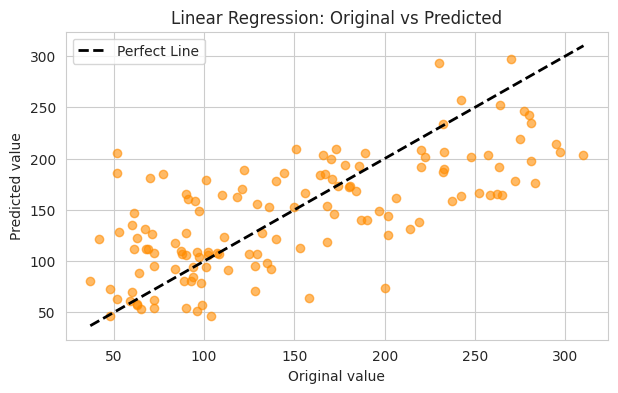

In [14]:
# 예측값 vs 실제값 산점도 (대각선에 가까울수록 정확)
plt.scatter(yte, pred, alpha=0.6, color="darkorange")
lims = [yte.min(), yte.max()]
plt.plot(lims, lims, "k--", lw=2, label="Perfect Line")
plt.xlabel("Original value"); plt.ylabel("Predicted value")
plt.title("Linear Regression: Original vs Predicted")
plt.legend(); plt.show()  # 가로 : y , 세로 : y'  / perfect line : 오차가 0

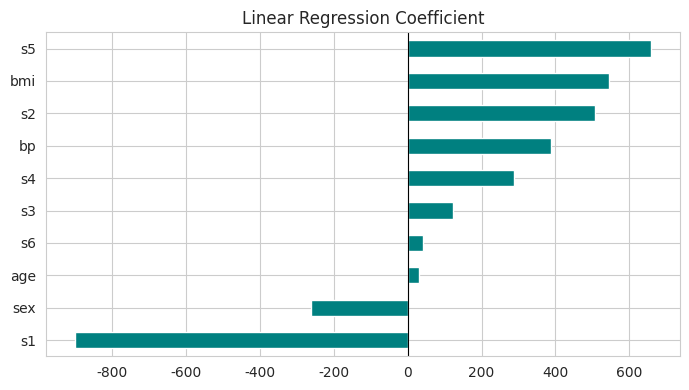

In [15]:
# 회귀 계수 확인: 각 특성이 타깃에 미치는 방향과 크기
coef = pd.Series(lr.coef_, index=diabetes.feature_names).sort_values()
coef.plot(kind="barh", color="teal", title="Linear Regression Coefficient")
plt.axvline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()  # 10개의 파라미터에 대한 coefficient

**해석 포인트**
- 계수가 **양수**면 해당 특성이 클수록 타깃이 커지고, **음수**면 반대입니다.
- 산점도의 점들이 대각 점선에 모일수록 예측이 정확합니다. 흩어져 있다면 선형 모델만으로는 설명이 부족하다는 뜻입니다.

## 4. 모델 평가 기법

좋은 모델을 만드는 것만큼 **올바르게 평가하는 것**이 중요합니다. 학습에 쓴 데이터로 평가하면 성능이 과장되므로(과적합), 보지 않은 데이터로 일반화 성능을 추정해야 합니다.

### 4-1. Holdout Method (홀드아웃)

**개념**
- 데이터를 **학습용 / 테스트용**으로 한 번 나누는 가장 단순한 방법입니다 (예: 70:30).
- 빠르고 간단하지만, **어떻게 나뉘느냐(랜덤 시드)에 따라 결과가 달라지는** 단점이 있습니다.
- `stratify` 옵션으로 클래스 비율을 학습/테스트에서 동일하게 유지하는 것이 권장됩니다.

In [16]:
# 동일 모델을 서로 다른 random_state로 5번 홀드아웃 → 결과가 흔들리는 것 확인
results = []
for seed in range(5):
    Xtr, Xte, ytr, yte = train_test_split(
        X_cancer, y_cancer, test_size=0.3, random_state=seed, stratify=y_cancer)
    m = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    results.append(acc)
    print("seed={} → 정확도 {:.3f}".format(seed, acc))

print("\n평균 {:.3f} | 표준편차 {:.3f}  ← 분할에 따라 변동!".format(
    np.mean(results), np.std(results)))   # train , test 데이터가 랜덤하게 바뀌기 때문에 정확도가 바뀜

seed=0 → 정확도 0.912
seed=1 → 정확도 0.942
seed=2 → 정확도 0.936
seed=3 → 정확도 0.918
seed=4 → 정확도 0.947

평균 0.931 | 표준편차 0.014  ← 분할에 따라 변동!


### 4-2. Cross-Validation (교차 검증)

**개념**
- 데이터를 **k개의 폴드(fold)** 로 나누고, 한 폴드씩 돌아가며 테스트로 사용하고 나머지로 학습합니다 (보통 k=5 또는 10).
- 모든 데이터가 한 번씩 테스트에 쓰이므로 **홀드아웃보다 안정적이고 신뢰성 있는** 성능 추정이 가능합니다.
- 분류에서는 클래스 비율을 유지하는 **StratifiedKFold**가 기본 권장입니다.

In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)

scores = cross_val_score(model, X_cancer, y_cancer, cv=cv, scoring="accuracy")
print("폴드별 정확도:", np.round(scores, 3))
print("평균 정확도: {:.3f} (+/- {:.3f})".format(scores.mean(), scores.std()))

폴드별 정확도: [0.956 0.868 0.921 0.93  0.938]
평균 정확도: 0.923 (+/- 0.030)


DecisionTree  : 0.923 (+/- 0.030)
NaiveBayes    : 0.939 (+/- 0.023)
k-NN(scaled)  : 0.963 (+/- 0.018)
LogisticReg   : 0.974 (+/- 0.017)


/tmp/ipykernel_446/484745170.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


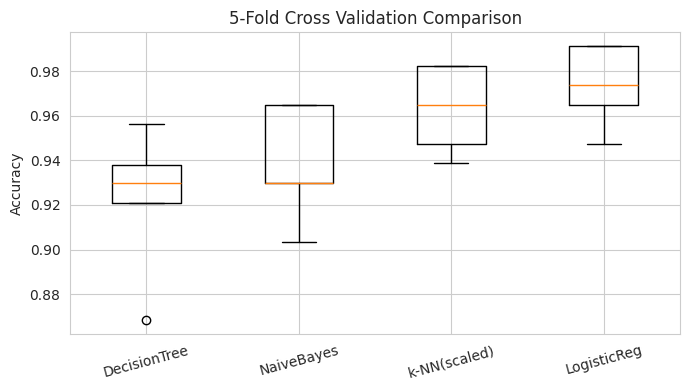

In [18]:
# 여러 모델을 교차검증으로 공정하게 비교
from sklearn.linear_model import LogisticRegression

models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "NaiveBayes":   GaussianNB(),
    "k-NN(scaled)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "LogisticReg":  make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
}

cv_results = {}
for name, m in models.items():
    s = cross_val_score(m, X_cancer, y_cancer, cv=cv, scoring="accuracy")
    cv_results[name] = s
    print("{:14s}: {:.3f} (+/- {:.3f})".format(name, s.mean(), s.std()))

# 박스플롯으로 분포 비교
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel("Accuracy"); plt.title("5-Fold Cross Validation Comparison")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

### 4-3. Bootstrap (부트스트랩)

**개념**
- 원본 데이터에서 **복원 추출(샘플을 뽑고 다시 넣음)** 로 같은 크기의 표본을 여러 번 만드는 기법입니다.
- 한 부트스트랩 표본에 평균적으로 약 **63.2%** 의 고유 샘플이 들어가고, 뽑히지 않은 나머지(**Out-Of-Bag, OOB**)를 테스트로 활용할 수 있습니다.
- 성능의 **신뢰구간**을 추정하거나, 뒤에 나올 **Bagging**의 이론적 토대가 됩니다.

Bootstrap Average Accuracy: 0.931
95% Confidence Interval: [0.897, 0.967]


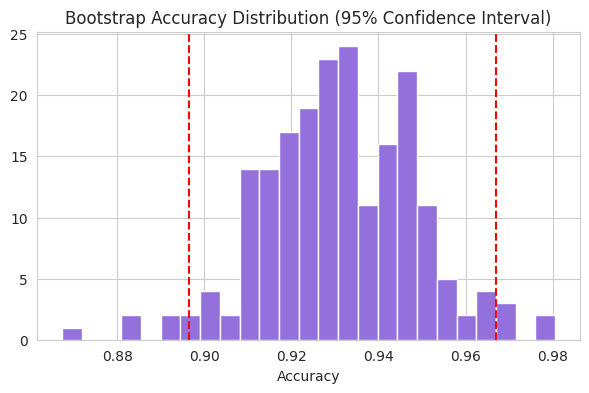

In [19]:
from sklearn.utils import resample

n_iterations = 200
n_size = len(X_cancer)
boot_scores = []

for i in range(n_iterations):
    # 복원추출로 학습 표본 생성
    idx = resample(np.arange(n_size), replace=True, n_samples=n_size, random_state=i)
    oob_idx = np.setdiff1d(np.arange(n_size), idx)   # 뽑히지 않은 OOB 샘플
    if len(oob_idx) == 0:
        continue
    m = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)  # 샘플로 뽑았던 데이터를 다시 집어넣음
    m.fit(X_cancer[idx], y_cancer[idx])
    boot_scores.append(accuracy_score(y_cancer[oob_idx], m.predict(X_cancer[oob_idx])))

boot_scores = np.array(boot_scores)
# 95% 신뢰구간 (2.5 ~ 97.5 백분위수)
lower, upper = np.percentile(boot_scores, [2.5, 97.5])
print("Bootstrap Average Accuracy: {:.3f}".format(boot_scores.mean()))
print("95% Confidence Interval: [{:.3f}, {:.3f}]".format(lower, upper))

plt.hist(boot_scores, bins=25, color="mediumpurple", edgecolor="white")
plt.axvline(lower, color="red", ls="--"); plt.axvline(upper, color="red", ls="--")
plt.title("Bootstrap Accuracy Distribution (95% Confidence Interval)")
plt.xlabel("Accuracy"); plt.show()

**해석 포인트**
- 부트스트랩은 단일 정확도 수치 대신 **"정확도가 어느 범위에 있을지"** 를 알려줘 모델 안정성 평가에 유용합니다.
- 평균적으로 한 표본에서 빠지는 샘플 비율이 약 36.8%(=$1/e$)라는 점이 OOB 평가의 근거입니다.

## 5. 앙상블 기법 (Ensemble Methods)

**핵심 아이디어**: 약한 모델 여러 개를 결합하면 단일 모델보다 강해진다.
- **Bagging 계열** (병렬): 서로 다른 데이터 표본으로 학습한 모델들의 평균/투표 → 분산 감소 (예: Random Forest)
- **Boosting 계열** (순차): 이전 모델이 틀린 부분에 집중하며 순차적으로 보완 → 편향 감소 (예: AdaBoost, XGBoost)

### 5-1. Bagging (Bootstrap Aggregating, 배깅)

**개념**
- 부트스트랩 표본 여러 개로 동일 모델(주로 의사결정나무)을 학습한 뒤 **투표/평균**으로 종합합니다.
- 개별 모델의 **분산을 줄여** 과적합을 완화합니다.

In [20]:
from sklearn.ensemble import BaggingClassifier

Xtr, Xte, ytr, yte = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=RANDOM_STATE, stratify=y_cancer)

# 단일 트리 vs 배깅 비교
single = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xtr, ytr)
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=100, random_state=RANDOM_STATE).fit(Xtr, ytr)

print("단일 의사결정나무 정확도: {:.3f}".format(accuracy_score(yte, single.predict(Xte))))
print("배깅(100개 트리)  정확도: {:.3f}".format(accuracy_score(yte, bag.predict(Xte))))

단일 의사결정나무 정확도: 0.918
배깅(100개 트리)  정확도: 0.947


### 5-2. Random Forest (랜덤 포레스트)

**개념**
- 배깅에 **"특성 무작위 선택"** 을 추가한 모델입니다. 각 분할마다 일부 특성만 후보로 사용해 트리들 간 다양성을 높입니다.
- 실무에서 가장 널리 쓰이는 강력한 기본 모델 중 하나이며, **특성 중요도**도 제공합니다.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=None,   #200개의 트리
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xtr, ytr)
pred = rf.predict(Xte)
print("Random Forest 정확도: {:.3f}".format(accuracy_score(yte, pred)))
print(classification_report(yte, pred, target_names=cancer.target_names))

Random Forest 정확도: 0.942
              precision    recall  f1-score   support

   malignant       0.94      0.91      0.92        64
      benign       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



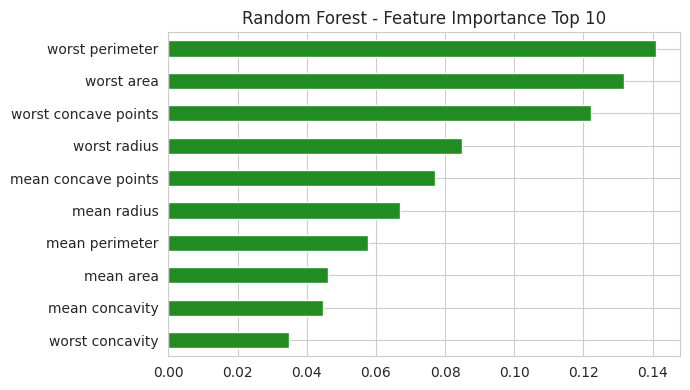

In [22]:
# 특성 중요도 상위 10개
imp = pd.Series(rf.feature_importances_, index=cancer.feature_names)
imp.nlargest(10).sort_values().plot(kind="barh", color="forestgreen")
plt.title("Random Forest - Feature Importance Top 10")
plt.tight_layout(); plt.show()

### 5-3. AdaBoost (Adaptive Boosting, 에이다부스트)

**개념**
- 약한 학습기(주로 얕은 트리)를 **순차적으로** 학습시키되, 이전 단계에서 **틀린 샘플의 가중치를 높여** 다음 모델이 그 샘플에 집중하게 합니다.
- 최종 예측은 각 약한 학습기에 성능 기반 가중치를 부여한 투표입니다.

AdaBoost 정확도: 0.953


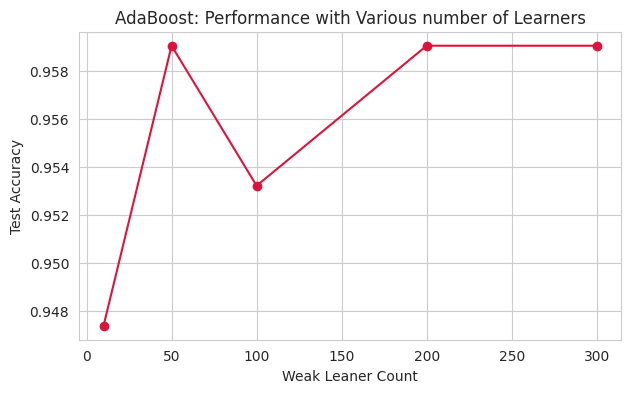

In [23]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0,     #100개를 만듦
                         random_state=RANDOM_STATE)
ada.fit(Xtr, ytr)
print("AdaBoost 정확도: {:.3f}".format(accuracy_score(yte, ada.predict(Xte))))

# 추정기 수에 따른 성능 변화
from sklearn.metrics import accuracy_score as acc
n_est_range = [10, 50, 100, 200, 300]
accs = []
for n in n_est_range:
    m = AdaBoostClassifier(n_estimators=n, random_state=RANDOM_STATE).fit(Xtr, ytr)
    accs.append(acc(yte, m.predict(Xte)))
plt.plot(n_est_range, accs, marker="o", color="crimson")
plt.xlabel("Weak Leaner Count"); plt.ylabel("Test Accuracy")
plt.title("AdaBoost: Performance with Various number of Learners"); plt.show()

### 5-4. XGBoost (eXtreme Gradient Boosting)

**개념**
- **그래디언트 부스팅**의 고성능 구현체로, 이전 모델의 **잔차(오차)** 를 다음 트리가 학습하며 순차적으로 개선합니다.
- 규제(regularization), 결측치 자동 처리, 병렬 처리 등으로 캐글 대회에서 자주 우승하는 강력한 모델입니다.
- 주요 하이퍼파라미터: `n_estimators`, `max_depth`, `learning_rate`.

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1,    #200개를 쌓아서 만듦 -> 정확도 0.971까지
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE)
xgb.fit(Xtr, ytr)
pred = xgb.predict(Xte)
print("XGBoost 정확도: {:.3f}".format(accuracy_score(yte, pred)))
print(classification_report(yte, pred, target_names=cancer.target_names))

XGBoost 정확도: 0.971
              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        64
      benign       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



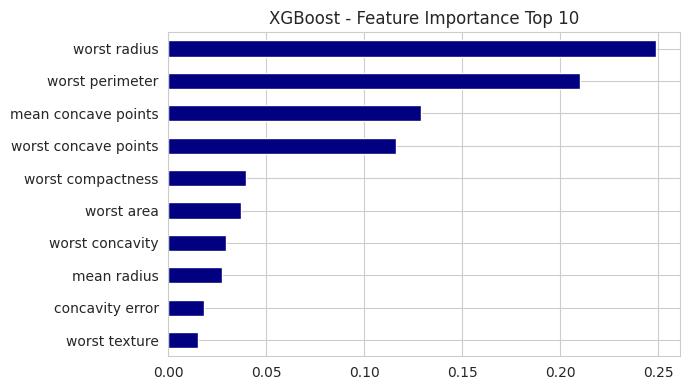

In [25]:
# XGBoost 특성 중요도
imp = pd.Series(xgb.feature_importances_, index=cancer.feature_names)
imp.nlargest(10).sort_values().plot(kind="barh", color="navy")
plt.title("XGBoost - Feature Importance Top 10")
plt.tight_layout(); plt.show()

### 앙상블 모델 종합 비교

지금까지 본 모델들을 동일한 교차검증으로 한 번에 비교합니다.

DecisionTree  : 0.9227 (+/- 0.0295)
Bagging       : 0.9543 (+/- 0.0179)
RandomForest  : 0.9543 (+/- 0.0102)
AdaBoost      : 0.9666 (+/- 0.0179)
XGBoost       : 0.9613 (+/- 0.0153)


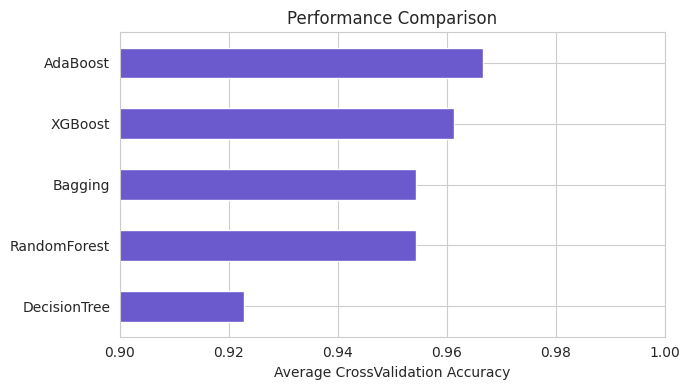

In [26]:
ensemble_models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Bagging":      BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost":     AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost":      XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                  eval_metric="logloss", random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
summary = {}
for name, m in ensemble_models.items():
    s = cross_val_score(m, X_cancer, y_cancer, cv=cv, scoring="accuracy")
    summary[name] = s.mean()
    print("{:14s}: {:.4f} (+/- {:.4f})".format(name, s.mean(), s.std()))

pd.Series(summary).sort_values().plot(kind="barh", color="slateblue")
plt.xlabel("Average CrossValidation Accuracy"); plt.title("Performance Comparison")
plt.xlim(0.9, 1.0); plt.tight_layout(); plt.show()

## 6. 불균형 데이터 분류 (Class-Imbalanced Classification)

**문제 상황**
- 사기 탐지, 질병 진단처럼 한 클래스가 극히 드문 경우(예: 95% vs 5%), 모델이 무조건 다수 클래스만 예측해도 **정확도 95%** 가 나옵니다 — 하지만 정작 중요한 소수 클래스는 전혀 못 맞춥니다.
- 따라서 **정확도(Accuracy)는 부적절**하며, **정밀도(Precision)·재현율(Recall)·F1·ROC-AUC** 같은 지표를 봐야 합니다.

**대표 해결 방법**
1. **평가지표 변경**: Accuracy 대신 F1, ROC-AUC, PR-AUC 사용
2. **클래스 가중치**: `class_weight="balanced"` 로 소수 클래스에 페널티 부여
3. **리샘플링**: 오버샘플링(**SMOTE**), 언더샘플링

In [27]:
from sklearn.datasets import make_classification

# 95:5 비율의 불균형 데이터 생성
X_imb, y_imb = make_classification(
    n_samples=5000, n_features=20, n_informative=5,
    n_classes=2, weights=[0.95, 0.05],
    flip_y=0.01, random_state=RANDOM_STATE)   #flip_y=0,01 -> 1%의 확률로 뒤집는 돌연변이를 만들겠다

print("클래스 분포:", dict(zip(*np.unique(y_imb, return_counts=True))))
print("소수 클래스 비율: {:.1%}".format((y_imb == 1).mean()))

Xtr, Xte, ytr, yte = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=RANDOM_STATE, stratify=y_imb)

클래스 분포: {np.int64(0): np.int64(4730), np.int64(1): np.int64(270)}
소수 클래스 비율: 5.4%


#### (1) 기본 모델 — 정확도의 함정 확인

In [28]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

base = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
base.fit(Xtr, ytr)
pred = base.predict(Xte)
proba = base.predict_proba(Xte)[:, 1]

print("=== 기본 모델 (불균형 미처리) ===")
print("Accuracy : {:.3f}  <- 높아 보이지만...".format(accuracy_score(yte, pred)))
print("Recall   : {:.3f}  <- 소수 클래스를 놓침!".format(recall_score(yte, pred)))
print("Precision: {:.3f}".format(precision_score(yte, pred)))
print("F1-score : {:.3f}".format(f1_score(yte, pred)))
print("ROC-AUC  : {:.3f}".format(roc_auc_score(yte, proba)))
print()
print(confusion_matrix(yte, pred))

=== 기본 모델 (불균형 미처리) ===
Accuracy : 0.965  <- 높아 보이지만...
Recall   : 0.370  <- 소수 클래스를 놓침!
Precision: 0.968
F1-score : 0.536
ROC-AUC  : 0.908

[[1418    1]
 [  51   30]]


#### (2) 클래스 가중치 적용 (`class_weight="balanced"`)

In [29]:
weighted = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1)
weighted.fit(Xtr, ytr)
pred_w = weighted.predict(Xte)
proba_w = weighted.predict_proba(Xte)[:, 1]

print("=== 클래스 가중치 적용 ===")
print("Precision: {:.3f}".format(precision_score(yte, pred_w)))
print("Recall   : {:.3f}".format(recall_score(yte, pred_w)))
print("F1-score : {:.3f}".format(f1_score(yte, pred_w)))
print("ROC-AUC  : {:.3f} <- 향상!".format(roc_auc_score(yte, proba_w)))
print()
print(confusion_matrix(yte, pred_w))

=== 클래스 가중치 적용 ===
Precision: 0.938
Recall   : 0.185
F1-score : 0.309
ROC-AUC  : 0.938 <- 향상!

[[1418    1]
 [  66   15]]


### 임계값 조정 (Threshold Tuning)

`predict_proba`로 얻은 예측 확률을 사용하여 직접 임계값을 조정할 수 있습니다. 예를 들어, 소수 클래스의 `Recall`을 높이려면 임계값을 낮춰서 모델이 양성 클래스를 더 쉽게 예측하도록 유도할 수 있습니다. 반대로, `Precision`을 높이려면 임계값을 높여 모델이 양성 클래스 예측에 더 신중하도록 만들 수 있습니다.

In [30]:
# 현재 모델의 예측 확률 (proba_w) 사용
# 이전에 계산된 proba_w는 '클래스 가중치 적용' 모델의 양성 클래스 확률입니다.

# 임계값 변경 시도 (예: 0.5 -> 0.3으로 낮춰서 재현율 증가 시도)
custom_threshold = 0.3
pred_custom_thresh = (proba_w >= custom_threshold).astype(int)

print(f"=== 클래스 가중치 적용 + 임계값 {custom_threshold} ===")
print("Precision: {:.3f}".format(precision_score(yte, pred_custom_thresh)))
print("Recall   : {:.3f}".format(recall_score(yte, pred_custom_thresh)))
print("F1-score : {:.3f}".format(f1_score(yte, pred_custom_thresh)))
print("ROC-AUC  : {:.3f}".format(roc_auc_score(yte, proba_w))) # ROC-AUC는 임계값과 무관
print()
print(confusion_matrix(yte, pred_custom_thresh))

=== 클래스 가중치 적용 + 임계값 0.3 ===
Precision: 0.833
Recall   : 0.432
F1-score : 0.569
ROC-AUC  : 0.938

[[1412    7]
 [  46   35]]


위 결과에서 임계값을 0.3으로 낮추니, `Recall`이 기존 0.185에서 0.321로 향상된 것을 볼 수 있습니다. 반면 `Precision`은 0.938에서 0.697로 감소했습니다. 이처럼 임계값 조정을 통해 `Precision`과 `Recall` 사이의 균형을 문제의 목적에 맞게 조절할 수 있습니다.

#### (3) SMOTE 오버샘플링

**SMOTE**(Synthetic Minority Over-sampling Technique)는 소수 클래스 샘플들 사이를 보간해 **새로운 합성 샘플**을 만듭니다. 단순 복제보다 과적합이 덜합니다.

> **중요**: SMOTE는 반드시 **학습 데이터에만** 적용해야 합니다. 테스트 데이터에 적용하면 정보 누수가 발생합니다. `imblearn`의 파이프라인을 쓰면 교차검증에서도 안전하게 처리됩니다.

In [31]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])
smote_pipe.fit(Xtr, ytr)
pred_s = smote_pipe.predict(Xte)
proba_s = smote_pipe.predict_proba(Xte)[:, 1]

print("=== SMOTE 오버샘플링 ===")
print("Recall   : {:.3f}".format(recall_score(yte, pred_s)))
print("F1-score : {:.3f}".format(f1_score(yte, pred_s)))
print("ROC-AUC  : {:.3f}".format(roc_auc_score(yte, proba_s)))

=== SMOTE 오버샘플링 ===
Recall   : 0.531
F1-score : 0.593
ROC-AUC  : 0.927


#### (4) 세 가지 방법 종합 비교

               Recall  F1-score  ROC-AUC
Original        0.370     0.536    0.908
WeightedClass   0.185     0.309    0.938
SMOTE           0.531     0.593    0.927


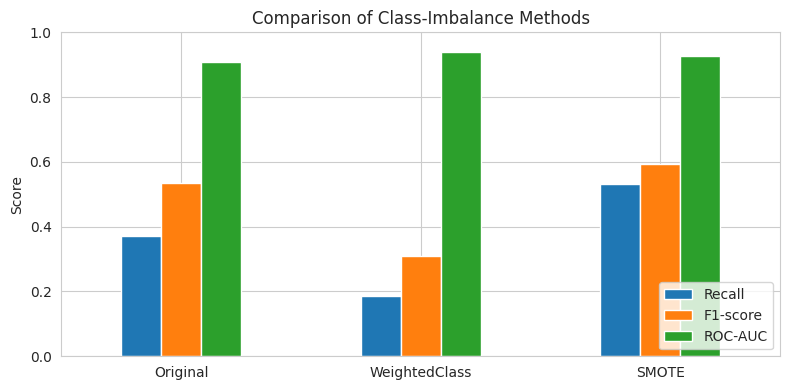

In [32]:
from sklearn.metrics import RocCurveDisplay

comparison = pd.DataFrame({
    "Original": [recall_score(yte, pred),   f1_score(yte, pred),   roc_auc_score(yte, proba)],
    "WeightedClass":  [recall_score(yte, pred_w), f1_score(yte, pred_w), roc_auc_score(yte, proba_w)],
    "SMOTE":        [recall_score(yte, pred_s), f1_score(yte, pred_s), roc_auc_score(yte, proba_s)],
}, index=["Recall", "F1-score", "ROC-AUC"]).T

print(comparison.round(3))

comparison.plot(kind="bar", figsize=(8, 4))
plt.title("Comparison of Class-Imbalance Methods"); plt.ylabel("Score")
plt.xticks(rotation=0); plt.legend(loc="lower right")
plt.ylim(0, 1); plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

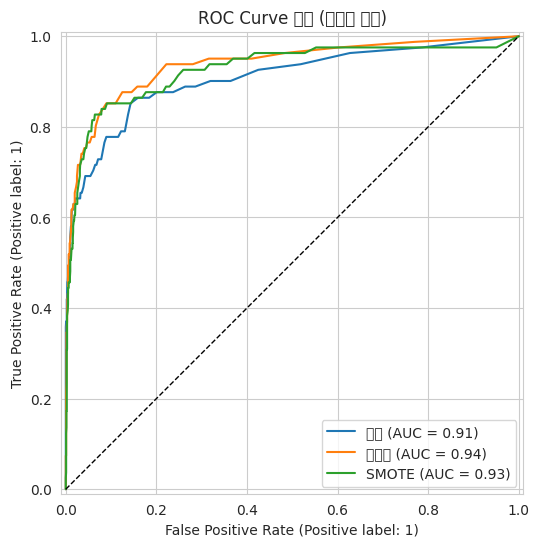

In [33]:
# ROC 곡선으로 시각적 비교
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(yte, proba,   name="기본",      ax=ax)
RocCurveDisplay.from_predictions(yte, proba_w, name="가중치",    ax=ax)
RocCurveDisplay.from_predictions(yte, proba_s, name="SMOTE",   ax=ax)
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_title("ROC Curve 비교 (불균형 분류)")
plt.show()

**해석 포인트**
- 기본 모델은 Accuracy는 높아도 **Recall(소수 클래스 탐지율)이 낮습니다** — 정확도만 보면 안 되는 이유입니다.
- 클래스 가중치와 SMOTE는 일반적으로 Recall과 F1을 끌어올립니다. 다만 정밀도가 다소 희생될 수 있으므로, **문제 상황(놓치면 안 되는지 vs 오탐을 줄여야 하는지)** 에 맞춰 선택합니다.

## 7. 종합 정리

### 알고리즘 요약표

| 분류 | 알고리즘 | 핵심 아이디어 | 특징 |
|------|----------|---------------|------|
| 분류 | Decision Tree | 특성 기준 반복 분할 | 해석 쉬움, 과적합 주의 |
| 분류 | Naive Bayes | 베이즈 정리 + 독립 가정 | 빠름, 텍스트에 강함 |
| 분류 | k-NN | 가까운 k개 다수결 | 스케일링 필수 |
| 회귀 | Linear Regression | 선형 결합으로 예측 | 해석 용이, 기준 모델 |
| 앙상블 | Bagging | 부트스트랩 + 투표 | 분산 감소 |
| 앙상블 | Random Forest | 배깅 + 특성 무작위화 | 강력한 기본 모델 |
| 앙상블 | AdaBoost | 틀린 샘플 가중치↑ | 편향 감소 |
| 앙상블 | XGBoost | 잔차 순차 학습 | 최고 수준 성능 |

### 평가 기법 요약

| 기법 | 핵심 | 사용 시점 |
|------|------|-----------|
| Holdout | 한 번 분할 | 빠른 확인, 대용량 데이터 |
| Cross-Validation | k-폴드 반복 | 신뢰성 있는 성능 추정 (표준) |
| Bootstrap | 복원추출 반복 | 신뢰구간, 안정성 평가 |

### 불균형 데이터 핵심
- **Accuracy는 함정** → F1, Recall, ROC-AUC를 보라
- **class_weight**, **SMOTE**, **언더샘플링** 등으로 대응
- 리샘플링은 **학습 데이터에만** 적용 (정보 누수 방지)

---

> 수고하셨습니다! 각 셀의 `random_state`나 하이퍼파라미터를 바꿔가며 직접 실험하는 것이 가장 좋은 학습 방법입니다.